In [1]:
from nb_utils import set_root

PROJECT_ROOT = set_root(level=2)


# Beta4-IRT and a CLAIRE-Ready Response Matrix

This notebook extends the classical binary IRT story. The objective is to show how a Beta4-style response function creates a clearer description of performance across easy and hard cases, and how this leads naturally to the response matrix used as input for CLAIRE.


## Learning Objectives

By the end of this notebook, students should be able to:

- inspect Beta4-style ICCs with clearly easy, medium, and hard cases;
- interpret item difficulty and effective discrimination in a toy latent-ability setting;
- compare raw observed performance with a latent-aware summary;
- build a response matrix `Pij` that can be used as input for CLAIRE.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.handson import (
    beta4_expected_response,
    make_response_matrix,
    plot_beta4_family,
    plot_iccs,
    plot_latent_accuracy,
    summarize_latent_results,
)


## Step 1: Create a Beta4 case table

The table below uses the parameter supports that we want to discuss in the workshop:

- difficulty in the interval `[0, 1]`;
- discrimination sign in `[-1, 1]`;
- discrimination magnitude in `[0, +inf)`.

The example is intentionally larger now, with clearly low-, medium-, and high-difficulty cases so the audience can read the curves more easily.


In [3]:
evaluation_cases = pd.DataFrame(
    [
        {
            'item': 'clear_signal_easy',
            'difficulty': 0.12,
            'discrimination_sign': 0.30,
            'discrimination_magnitude': 0.50,
            'difficulty_group': 'low',
        },
        {
            'item': 'routine_pattern_easy',
            'difficulty': 0.22,
            'discrimination_sign': 0.45,
            'discrimination_magnitude': 0.80,
            'difficulty_group': 'low',
        },
        {
            'item': 'mixed_cues_medium',
            'difficulty': 0.45,
            'discrimination_sign': 0.65,
            'discrimination_magnitude': 1.00,
            'difficulty_group': 'medium',
        },
        {
            'item': 'borderline_medium',
            'difficulty': 0.58,
            'discrimination_sign': 0.75,
            'discrimination_magnitude': 1.20,
            'difficulty_group': 'medium',
        },
        {
            'item': 'rare_pattern_hard',
            'difficulty': 0.78,
            'discrimination_sign': 0.90,
            'discrimination_magnitude': 1.50,
            'difficulty_group': 'high',
        },
        {
            'item': 'confounding_hard',
            'difficulty': 0.90,
            'discrimination_sign': 0.95,
            'discrimination_magnitude': 1.90,
            'difficulty_group': 'high',
        },
    ]
)

evaluation_cases['effective_discrimination'] = (
    evaluation_cases['discrimination_sign'] * evaluation_cases['discrimination_magnitude']
)

evaluation_cases.round(3)


,item,difficulty,discrimination_sign,discrimination_magnitude,effective_discrimination
0,supportive_case,0.15,0.35,0.6,0.210
1,boundary_case,0.50,0.75,1.1,0.825
2,strict_case,0.85,0.95,1.8,1.710


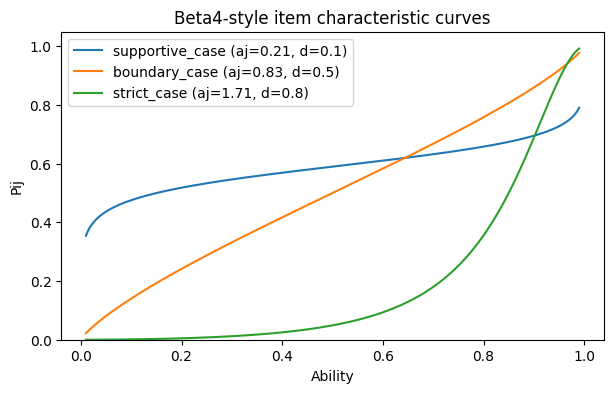

In [4]:
theta_grid = np.linspace(0.01, 0.99, 300)
ax = plot_iccs(evaluation_cases, theta=theta_grid)
plt.show()


## Step 2: Inspect the Beta4 family

In this plot we select representative low-, medium-, and high-difficulty cases and inspect how the response curves change. This makes the link between difficulty, discrimination, and model ability easier to explain in the talk.


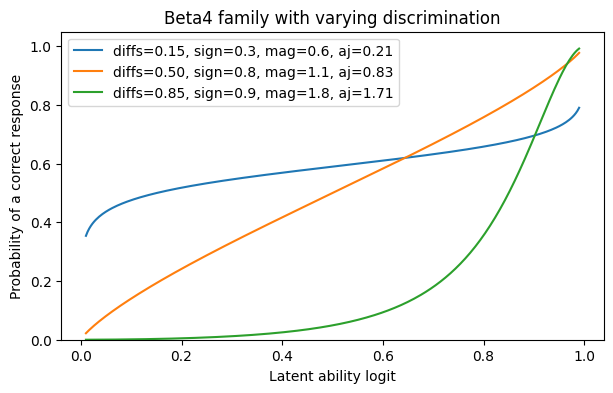

In [5]:
ax = plot_beta4_family(
    theta=theta_grid,
    parameter_pairs=[
        (0.12, 0.30, 0.50),
        (0.58, 0.75, 1.20),
        (0.90, 0.95, 1.90),
    ],
)
plt.show()


## Step 3: Simulate a latent-ability evaluation setting

We now simulate several models answering the same set of cases. In this toy example, we know the latent quantities used to generate the data.

For the workshop, this is helpful because students can first learn the interpretation before moving to the response matrix used by CLAIRE.


In [12]:
ability_grid = np.linspace(0.10, 0.90, 8)
rng = np.random.default_rng(21)
rows = []

for index, ability in enumerate(ability_grid, start=1):
    for row in evaluation_cases.itertuples(index=False):
        probability = float(
            beta4_expected_response(
                theta=ability,
                difficulty=row.difficulty,
                discrimination=None,
                discrimination_sign=row.discrimination_sign,
                discrimination_magnitude=row.discrimination_magnitude,
            )
        )
        rows.append(
            {
                'model': f'model_{index}',
                'ability': ability,
                'item': row.item,
                'difficulty': row.difficulty,
                'difficulty_group': row.difficulty_group,
                'discrimination_sign': row.discrimination_sign,
                'discrimination_magnitude': row.discrimination_magnitude,
                'effective_discrimination': row.effective_discrimination,
                'expected_probability': probability,
                'observed_correct': int(rng.binomial(1, probability)),
            }
        )

responses = pd.DataFrame(rows)
responses.head(12)


,model,ability,item,difficulty,difficulty_probability,discrimination_sign,discrimination_magnitude,effective_discrimination,expected_probability,observed_correct
0,model_1,0.10,supportive_case,0.15,0.15,0.35,0.6,0.210,0.475731,1
1,model_1,0.10,boundary_case,0.50,0.50,0.75,1.1,0.825,0.140311,0
2,model_1,0.10,strict_case,0.85,0.85,0.95,1.8,1.710,0.001201,0
3,model_2,0.26,supportive_case,0.15,0.15,0.35,0.6,0.210,0.536090,1
4,model_2,0.26,boundary_case,0.50,0.50,0.75,1.1,0.825,0.296729,0
5,model_2,0.26,strict_case,0.85,0.85,0.95,1.8,1.710,0.008537,0
6,model_3,0.42,supportive_case,0.15,0.15,0.35,0.6,0.210,0.573583,1
7,model_3,0.42,boundary_case,0.50,0.50,0.75,1.1,0.825,0.433819,0
8,model_3,0.42,strict_case,0.85,0.85,0.95,1.8,1.710,0.028801,0


In [13]:
observed_response_matrix = make_response_matrix(responses, value_column='observed_correct')
observed_response_matrix


item,boundary_case,strict_case,supportive_case
model,,,
model_1,0,0,1
model_2,0,0,1
model_3,0,0,1
model_4,1,0,0
model_5,1,1,0
model_6,1,1,0


In [14]:
latent_summary = summarize_latent_results(responses)
latent_summary.round(3)


,model,ability,mean_expected_probability,observed_accuracy
0,model_1,0.10,0.206,0.333
1,model_2,0.26,0.280,0.333
2,model_3,0.42,0.345,0.333
3,model_4,0.58,0.418,0.333
4,model_5,0.74,0.527,0.667
5,model_6,0.90,0.748,0.667


In [15]:
pij_matrix = make_response_matrix(responses, value_column='expected_probability')
pij_matrix.round(3)


,model,observed_accuracy,expected_probability,mean_effective_discrimination,mean_difficulty_probability
5,model_6,0.667,0.748,0.915,0.5
4,model_5,0.667,0.527,0.915,0.5
3,model_4,0.333,0.418,0.915,0.5
2,model_3,0.333,0.345,0.915,0.5
1,model_2,0.333,0.280,0.915,0.5
0,model_1,0.333,0.206,0.915,0.5


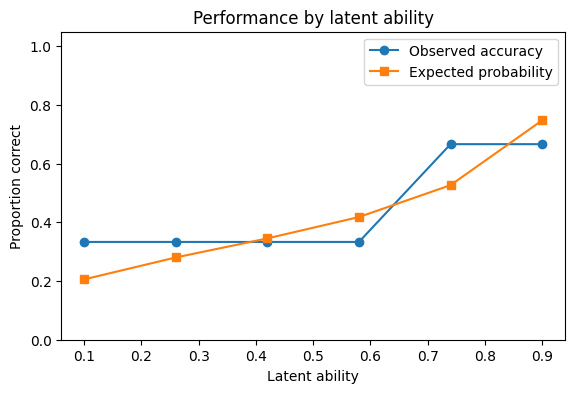

In [16]:
ax = plot_latent_accuracy(latent_summary)
plt.show()


## Step 4: Build the response matrix `Pij`

Instead of moving directly to CLAIRE, we stop at the matrix representation that CLAIRE uses as input.

Here the notation follows the usual idea of a response matrix `Pij`:

- each row `i` represents a model;
- each column `j` represents an item or case;
- each cell `Pij` stores the probability that model `i` answers item `j` correctly.

In this notebook, the `pij_matrix` above is the CLAIRE-ready object: it summarizes how likely each model is to solve each case, while preserving the variation across low-, medium-, and high-difficulty items.


## Activity: From Beta4 Cases to the `Pij` Matrix

Ask students to answer the following:

1. Which items are clearly low difficulty, medium difficulty, and high difficulty?
2. Looking at the ICCs, which hard item seems most selective?
3. In the `pij_matrix`, which models are consistently strong across the high-difficulty items?
4. Why is the `Pij` matrix more informative than a single aggregate metric?


In [11]:
# Student workspace
# Suggested mini-task:
# 1. Filter the columns associated with high-difficulty items.
# 2. Rank the models by their mean Pij on those items.

high_difficulty_items = evaluation_cases.loc[
    evaluation_cases['difficulty_group'] == 'high', 'item'
].tolist()

pij_matrix[high_difficulty_items].mean(axis=1).sort_values(ascending=False)


,model,observed_accuracy,expected_probability
5,model_6,0.666667,0.747732
4,model_5,0.666667,0.526910
3,model_4,0.333333,0.418213
2,model_3,0.333333,0.345401
1,model_2,0.333333,0.280452
0,model_1,0.333333,0.205748


## Suggested oral closing

The notebook can end with the following message: **Beta4 helps us describe response behavior across cases, and the response matrix `Pij` is the bridge from that interpretation to CLAIRE**.
